## Clustering jerárquico aglomerativo en un dataset médico (Diabetes)




## 0) Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


## 1) Cargar dataset y preparar `X` y `y`

In [2]:
data = load_diabetes(as_frame=True)
X = data.data.copy()
y = pd.Series(data.target, name="disease_progression")

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()


X shape: (442, 10)
y shape: (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


## 2) Escalado 

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("X_scaled shape:", X_scaled.shape)
print("Media (debe ser ~0):", X_scaled.mean(axis=0).round(2))
print("Std (debe ser ~1):", X_scaled.std(axis=0).round(2))

X_scaled shape: (442, 10)
Media (debe ser ~0): [ 0.  0. -0. -0. -0.  0.  0.  0. -0. -0.]
Std (debe ser ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 3) Elegir `k` (número de clusters) con silhouette
Probamos k=2..6 y elegimos el que maximiza silhouette.

Silhouette por k: {2: 0.18, 3: 0.125, 4: 0.113, 5: 0.101, 6: 0.105}
Mejor k: 2


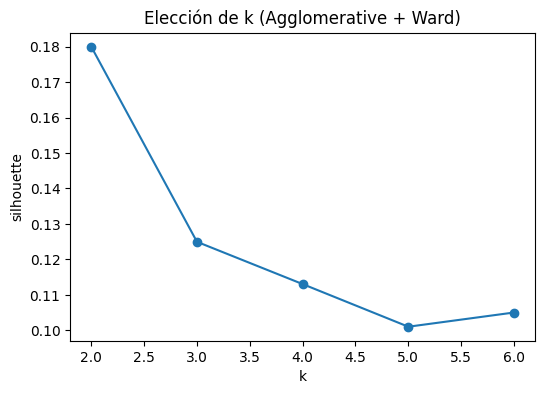

In [4]:
ks = range(2, 7)
scores = []

#pon tu código aquí:
#1.- Llama al modelo AgglomerativeClustering ()
#2.- Haz el fit y obten los clusters (labels)
#3.- Obten el valor de silhouette 
for k in ks:
    model   = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels  = model.fit_predict(X_scaled)
    s = silhouette_score(X_scaled, labels)
    scores.append(s)

#pon tu código aquí: ordena la lista 'scores' y quedate con el valor MAS ALTO
best_k = ks[np.argmax(scores)]

print("Silhouette por k:", dict(zip(ks, [round(v, 3) for v in scores])))
print("Mejor k:", best_k)

plt.figure(figsize=(6,4))
plt.plot(list(ks), scores, marker="o")
plt.xlabel("k")
plt.ylabel("silhouette")
plt.title("Elección de k (Agglomerative + Ward)")
plt.show()


## 4) Entrenar el modelo final con `k = best_k`

In [5]:
#PON TU CODIGO AQUI
k = best_k
model_final = AgglomerativeClustering(n_clusters=k, linkage="ward")
labels = model_final.fit_predict(X_scaled)

print("Tamaños de clusters:", np.bincount(labels))


Tamaños de clusters: [285 157]


## 5) Visualización: PCA 2D coloreado por cluster

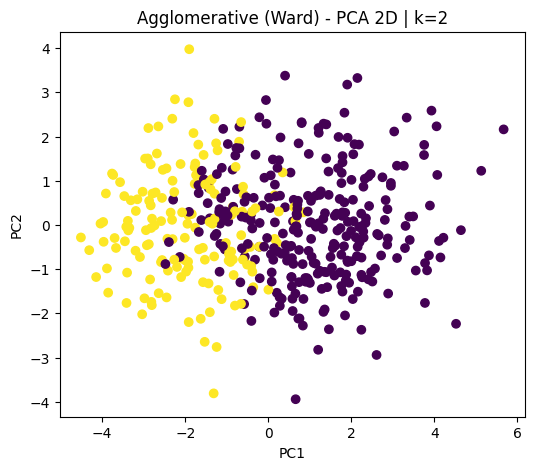

In [6]:
pca = PCA(n_components=2, random_state=0)
X_2d = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels)
plt.title(f"Agglomerative (Ward) - PCA 2D | k={k}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()
